# Extra baselines — Sven vs the full optimizer suite

Best configuration per optimizer on the headline scans, **all** baselines included, selected
by seed-mean final **validation** loss like everywhere else.  Every configuration is scored by its
**seed-mean** final loss (diverged runs excluded and counted; A4), with the clipped seed
error bar (A5).  `METRIC` picks the loss used for both selection and display.

The earlier version of this notebook was run on separate `rebuttal_baselines_*` result
directories; those runs now live in the headline scans, which this notebook loads.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import scan_analysis as sa
from style import set_style, clipped_yerr, method_color, DATASET_TITLES, metric_label

set_style()

In [2]:
# METRIC: selection (and the bars) use the final VALIDATION loss, like every other notebook; the
# table shows the train loss of the same configs alongside.
METRIC = 'final_val_loss'
PLOT_DIR = Path('plots_v2/baselines')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

SCANS = {key: (name, DATASET_TITLES[key]) for key, name in [
    ('toy_1d', 'toy_1d_scan'), ('polynomial', 'polynomial_scan'),
    ('mnist_labelreg', 'mnist_scan_labelRegression'), ('mnist_ce', 'mnist_scan_ce')]}
scans, tables = {}, {}
for key, (name, title) in SCANS.items():
    try:
        scans[key] = sa.load_scan(name, title, PLOT_DIR, metric=METRIC)
    except FileNotFoundError:
        print(f'  [skip] {name}: not found')
        continue
    tables[key] = sa.summary_table(scans[key], metric=METRIC)   # baselines=None -> every optimizer present

Loaded 714 runs from ../experiment_results/_cache/toy_1d_scan.slim.pkl (slim cache)
toy_1d_scan: 714 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32] rtol=[0.0001, 0.001, 0.01]
  95 diverged run(s), excluded from seed means: {'LBFGS': 48, 'SVD': 39, 'KFAC': 8}
Loaded 711 runs from ../experiment_results/_cache/polynomial_scan.slim.pkl (slim cache)
polynomial_scan: 711 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32] rtol=[0.0001, 0.001, 0.01]
  94 diverged run(s), excluded from seed means: {'LBFGS': 88, 'KFAC': 4, 'SOAP': 2}


Loaded 979 runs from ../experiment_results/_cache/mnist_scan_labelRegression.slim.pkl (slim cache)
mnist_scan_labelRegression: 979 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32, 48, 64] rtol=[0.0001, 0.001, 0.01, 0.1]
  100 diverged run(s), excluded from seed means: {'LBFGS': 96, 'HIG': 2, 'SOAP': 1, 'SVD': 1}
Loaded 1020 runs from ../experiment_results/_cache/mnist_scan_ce.slim.pkl (slim cache)
mnist_scan_ce: 1020 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32, 48, 64] rtol=[0.0001, 0.001, 0.01, 0.1]
  35 diverged run(s), excluded from seed means: {'LBFGS': 30, 'HIG': 2, 'SOAP': 2, 'SVD': 1}


## 2. Best final loss per optimizer

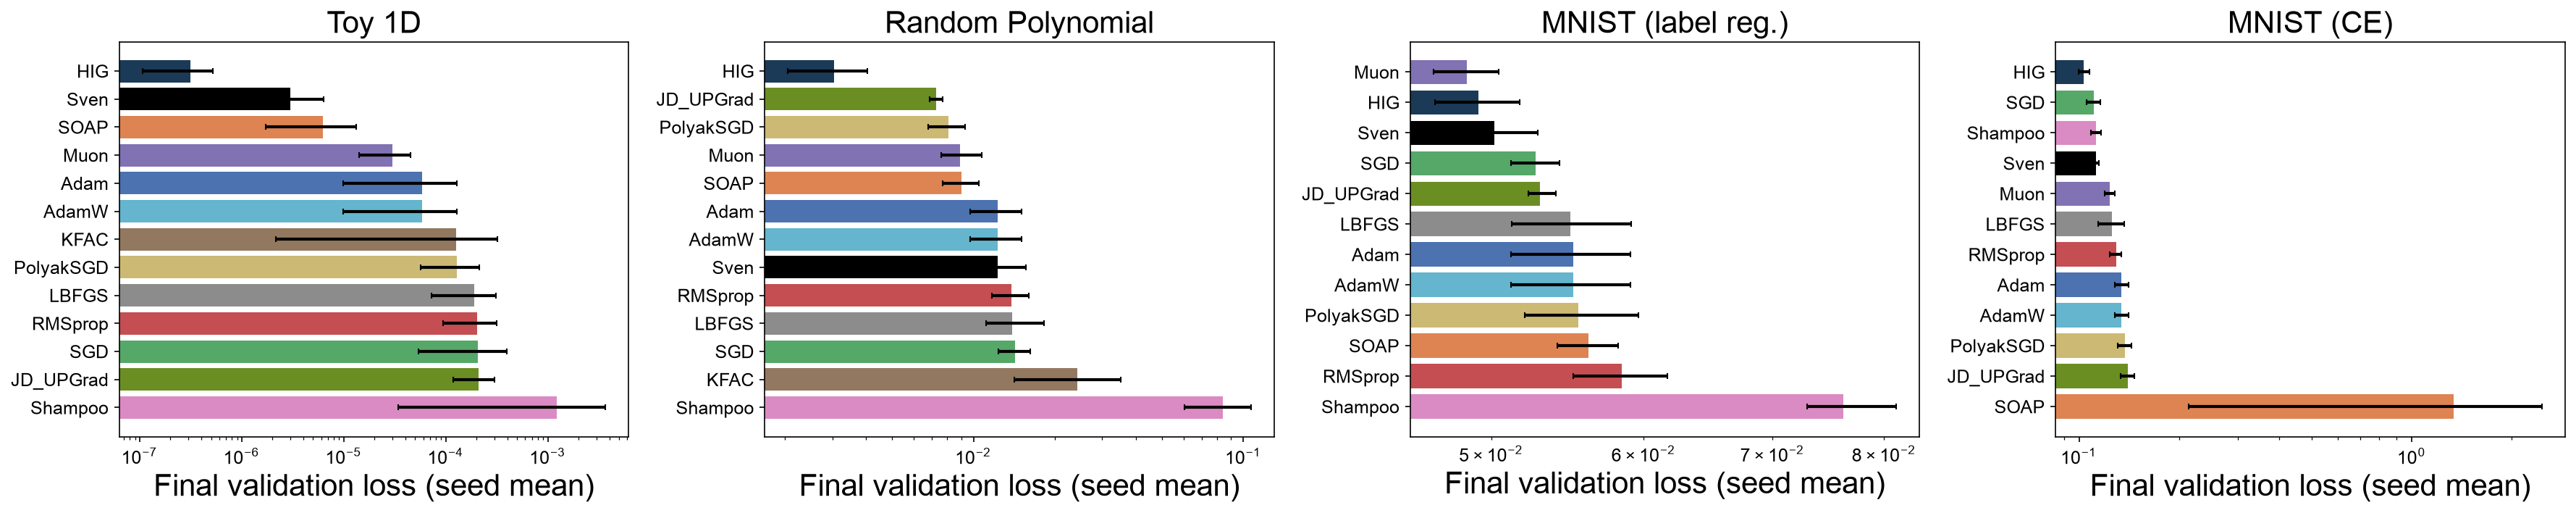

In [3]:
fig, axes = plt.subplots(1, len(tables), figsize=(6 * len(tables), 5), squeeze=False)
for ax, (key, t) in zip(axes[0], tables.items()):
    t = t.sort_values(METRIC)
    ax.barh(t['method'], t[METRIC], xerr=clipped_yerr(t[METRIC], t[f'{METRIC}_std'], t[f'{METRIC}_min']),
            capsize=2, color=[method_color(m) for m in t['method']])
    ax.set_xscale('log'); ax.invert_yaxis()
    ax.set_title(scans[key].title)
    ax.set_xlabel(metric_label(METRIC))
fig.tight_layout()
fig.savefig(PLOT_DIR / 'best_loss_by_optimizer.pdf', bbox_inches='tight')
plt.show()

## 3. Table

In [4]:
cols = ['method', 'config', 'n_seeds', 'n_diverged', METRIC, f'{METRIC}_std',
        'final_val_loss' if METRIC != 'final_val_loss' else 'final_train_loss']
for key, t in tables.items():
    print(f'== {scans[key].title} ==  (best config per optimizer by seed-mean {METRIC})')
    print(t[[c for c in cols if c in t]].to_string(index=False, float_format=lambda v: f'{v:.3e}'))
    print()

== Toy 1D ==  (best config per optimizer by seed-mean final_val_loss)
   method                                             config  n_seeds  n_diverged  final_val_loss  final_val_loss_std  final_train_loss
      HIG                                 lr=0.1, tau=0.0001        5           0       3.126e-07           2.066e-07         1.093e-07
     Sven                           k=16, lr=0.1, rtol=0.001        5           0       2.967e-06           3.414e-06         7.956e-07
     SOAP                                           lr=0.001        5           0       6.247e-06           7.047e-06         4.554e-06
     Muon                                           lr=0.001        5           0       2.975e-05           1.566e-05         3.575e-05
     Adam                                            lr=0.01        5           0       5.872e-05           6.983e-05         2.694e-05
    AdamW                                            lr=0.01        5           0       5.872e-05           6.983e